# Modelo 2 — Previsão do vetor **por bairro** (experiência exploratória)

Enquanto o **Modelo 1** prevê **casos** na **cidade inteira**, aqui o alvo muda para o que o **PEP pede literalmente**: a **abundância do vetor** (*Aedes aegypti*) **por bairro**.

- **Dados:** capturas da **Marília (2019–2023)** — 68 bairros, ~236 mil capturas por armadilha (`saida_*.csv`).
- **Alvo:** densidade de *Aedes aegypti* por armadilha, por **bairro × semana**. *(casos por bairro não entram: o SINAN não traz bairro confiável.)*
- **Pergunta:** dá pra prever o vetor por bairro? E a **vizinhança espacial** (bairros vizinhos) **agrega**?
- **Método:** igual ao Modelo 1 — **multi-horizonte direto + walk-forward** —, comparando **só lags do bairro × + vizinhança**.

> ⚠️ **Exploratório, 1ª passada.** Semana sem captura tratada como densidade 0; clima da Marília está vazio (não usado aqui); vizinhança por KNN das coordenadas (sem shapefile). A ser aprofundado com a série histórica e o shapefile real dos bairros.

## 1. Ambiente

In [1]:
import importlib.util as u
for m in ["pandas", "numpy", "matplotlib", "sklearn", "lightgbm"]:
    print(f"{m:12s}", "OK" if u.find_spec(m) else "FALTA  ->  pip install")

pandas       OK
numpy        OK
matplotlib   OK
sklearn      OK
lightgbm     OK


## 2. Capturas por bairro (Marília 2019–2023)

Cada linha de `saida_*.csv` é uma captura em uma armadilha georreferenciada. A coluna **`Local`** é o **bairro**. Agregamos para **densidade de *Aedes aegypti* por armadilha** em cada `bairro × semana`.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd


def achar_raiz(marcador="Raspagem"):
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / marcador).is_dir():
            return p
    raise FileNotFoundError("raiz não encontrada")


RAIZ = achar_raiz()
DIR = RAIZ / "Bases de dados" / "dados_marilia"

cap = pd.concat([pd.read_csv(DIR / f"saida_{y}.csv", sep=";") for y in range(2019, 2024)], ignore_index=True)
cap["bairro"] = cap["Local"].astype(str).str.upper().str.strip()
# coordenadas/contagens podem vir como texto entre os anos -> força numérico
for c in ["Latitude", "Longitude", "Aedes aegypti", "Aedes albopictus", "Culex sp"]:
    cap[c] = pd.to_numeric(cap[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")

print("capturas:", cap.shape, "| bairros:", cap["bairro"].nunique())
cap[["bairro", "Ano", "Semana", "Latitude", "Longitude", "Aedes aegypti"]].head(3)

capturas: (235755, 16) | bairros: 68


,bairro,Ano,Semana,Latitude,Longitude,Aedes aegypti
0,CAVALHADA,2019,1,-30.103,-51.247,0
1,CAVALHADA,2019,1,-30.103,-51.250,0
2,CAVALHADA,2019,1,-30.105,-51.512,0


In [3]:
painel = (cap.groupby(["bairro", "Ano", "Semana"])
          .agg(aegypti=("Aedes aegypti", "sum"), n=("ID", "count"),
               lat=("Latitude", "mean"), lon=("Longitude", "mean"))
          .reset_index())
painel["dens"] = painel["aegypti"] / painel["n"]   # Aedes aegypti por armadilha (analogo ao IMFA)

# indice de semana continuo (0,1,2,...) ordenado no tempo
sem = painel[["Ano", "Semana"]].drop_duplicates().sort_values(["Ano", "Semana"]).reset_index(drop=True)
sem["t"] = np.arange(len(sem))
painel = painel.merge(sem, on=["Ano", "Semana"])
print("semanas:", len(sem), "| painel (bairro x semana):", painel.shape)
painel.head(3)

semanas: 232 | painel (bairro x semana): (12134, 9)


,bairro,Ano,Semana,aegypti,n,lat,lon,dens,t
0,APARICIO BORGES,2019,1,0,29,-30.071414,-51.183586,0.000000,0
1,APARICIO BORGES,2019,2,0,29,-30.071414,-51.183586,0.000000,1
2,APARICIO BORGES,2019,3,8,29,-30.071414,-51.183586,0.275862,2


## 3. Grade `bairro × semana` + vizinhança espacial (KNN)

Para ter **lags regulares**, completamos a grade (toda semana para todo bairro; semana sem captura = densidade 0). A **vizinhança** de cada bairro são os **K=4 bairros mais próximos** pelo centroide (média das coordenadas das armadilhas) — a feature é a **densidade média desses vizinhos**.

In [4]:
from sklearn.neighbors import NearestNeighbors

bairros = sorted(painel["bairro"].unique())
grid = pd.MultiIndex.from_product([bairros, sem["t"].values], names=["bairro", "t"]).to_frame(index=False)
df = (grid.merge(painel[["bairro", "t", "dens"]], on=["bairro", "t"], how="left")
          .merge(sem[["t", "Semana"]], on="t", how="left"))
df["dens"] = df["dens"].fillna(0.0)
df = df.sort_values(["bairro", "t"]).reset_index(drop=True)

cent = painel.groupby("bairro")[["lat", "lon"]].mean().loc[bairros]
K = 4
_, idx = NearestNeighbors(n_neighbors=K + 1).fit(cent.values).kneighbors(cent.values)
viz_de = {bairros[i]: [bairros[j] for j in idx[i][1:]] for i in range(len(bairros))}  # exclui o proprio

piv = df.pivot(index="t", columns="bairro", values="dens")
viz = pd.DataFrame({b: piv[viz_de[b]].mean(axis=1) for b in bairros})
df = df.merge(viz.reset_index().melt(id_vars="t", var_name="bairro", value_name="viz"), on=["t", "bairro"], how="left")
print("grade completa:", df.shape, "| K vizinhos:", K)

grade completa: (15776, 5) | K vizinhos: 4


## 4. Features (no momento da previsão)

In [5]:
g = df.groupby("bairro", group_keys=False)
for k in [1, 2, 3, 4]:
    df[f"dens_lag{k}"] = g["dens"].shift(k)     # densidade do proprio bairro
    df[f"viz_lag{k}"] = g["viz"].shift(k)        # densidade dos bairros vizinhos
df["dens_mm4"] = g["dens"].transform(lambda s: s.rolling(4).mean())
df["sin"] = np.sin(2 * np.pi * df["Semana"] / 52)
df["cos"] = np.cos(2 * np.pi * df["Semana"] / 52)

feat_own = [f"dens_lag{k}" for k in [1, 2, 3, 4]] + ["dens_mm4", "sin", "cos"]
feat_viz = feat_own + [f"viz_lag{k}" for k in [1, 2, 3, 4]]
print("features SO bairro:", len(feat_own), "| + vizinhanca:", len(feat_viz))

features SO bairro: 7 | + vizinhanca: 11


## 5. Walk-forward multi-horizonte — **só bairro × + vizinhança**

Um modelo por horizonte (1–4 semanas), treinando só com o passado (janela expansível) e prevendo todos os bairros na semana de teste. Rodamos **duas vezes**: sem e com as features de vizinhança, para medir o **lift espacial**.

In [6]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error

PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=20, verbose=-1, n_jobs=-1)


def avaliar(feats, horizontes=range(1, 5), min_t=120, passo=4):
    gg = df.groupby("bairro", group_keys=False)
    Tmax = int(df["t"].max())
    out = []
    for h in horizontes:
        d = df.copy()
        d["y"] = gg["dens"].shift(-h)
        dd = d.dropna(subset=feats + ["y"])
        for i in range(min_t, Tmax - h + 1, passo):
            tr, te = dd[dd["t"] < i], dd[dd["t"] == i]
            if len(te) == 0 or len(tr) < 200:
                continue
            m = LGBMRegressor(**PARAMS).fit(tr[feats], tr["y"])
            out.append(pd.DataFrame({"h": h, "real": te["y"].values, "pred": m.predict(te[feats])}))
    return pd.concat(out, ignore_index=True)


def metrica(res):
    return res.groupby("h").apply(lambda x: pd.Series({"R2": r2_score(x.real, x.pred),
                                                        "MAE": mean_absolute_error(x.real, x.pred)}),
                                  include_groups=False)


m_own = metrica(avaliar(feat_own))
m_viz = metrica(avaliar(feat_viz))
tab = pd.DataFrame({"R2_so_bairro": m_own["R2"], "R2_com_vizinhanca": m_viz["R2"],
                    "ganho_R2": m_viz["R2"] - m_own["R2"]}).round(3)
tab

,R2_so_bairro,R2_com_vizinhanca,ganho_R2
h,,,
1,0.544,0.546,0.002
2,0.363,0.368,0.005
3,0.267,0.323,0.056
4,0.480,0.489,0.009


## 6. Resultado — a vizinhança espacial agrega?

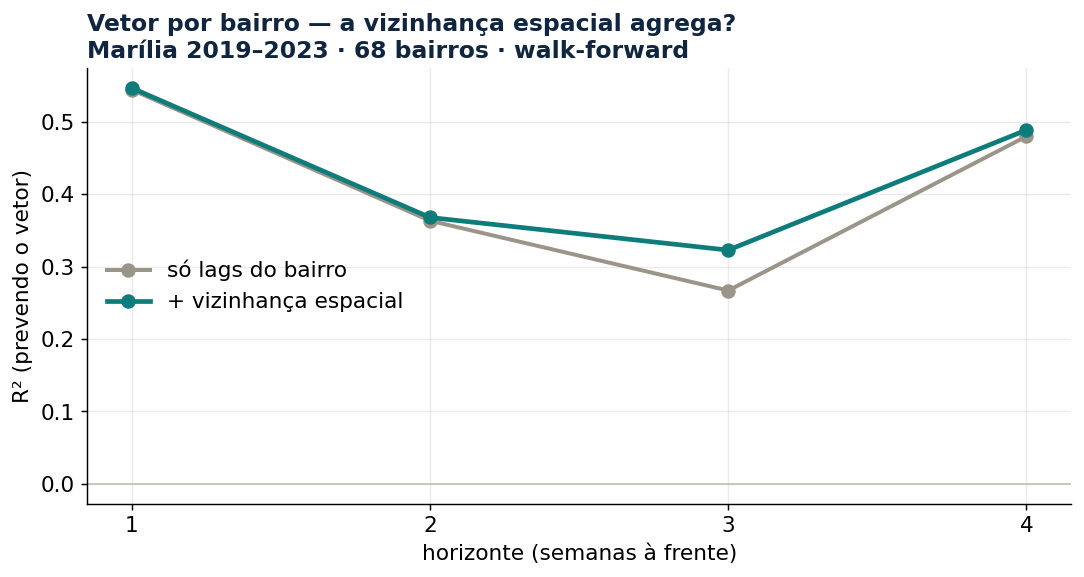

In [7]:
import matplotlib.pyplot as plt

TEAL, INK = "#0e7c7b", "#0f2540"
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 130})
fig, ax = plt.subplots(figsize=(8.5, 4.6))
hs = m_own.index
ax.plot(hs, m_own["R2"], "o-", color="#9b9488", lw=2.2, ms=7, label="só lags do bairro")
ax.plot(hs, m_viz["R2"], "o-", color=TEAL, lw=2.6, ms=7, label="+ vizinhança espacial")
ax.axhline(0, color="#c9c2b4", lw=1)
ax.set_xlabel("horizonte (semanas à frente)")
ax.set_ylabel("R² (prevendo o vetor)")
ax.set_title("Vetor por bairro — a vizinhança espacial agrega?\nMarília 2019–2023 · 68 bairros · walk-forward",
             fontsize=13, fontweight="bold", color=INK, loc="left")
ax.set_xticks(list(hs))
ax.legend(frameon=False)
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig("bairro_lift_espacial.png", bbox_inches="tight", facecolor="white")
plt.show()

## 7. Leitura honesta + próximos passos

- **Dá para prever o vetor por bairro** (R² ~0,3–0,5 nos horizontes curtos) — viável modelar a abundância do *Aedes* na escala que o PEP pede.
- A **vizinhança espacial agrega um ganho pequeno** (mais visível ~3 semanas) — sinal de que a estrutura espacial do vetor carrega informação, mas modesto nesta 1ª passada.
- **Ressalvas:** semana sem captura = 0 (simplificação); sem clima por bairro; vizinhança por KNN de coordenadas, não por adjacência real (falta shapefile); só o bloco Marília (2019–2023).
- **Próximos passos:** shapefile real dos bairros (adjacência); incluir clima por bairro (NASA POWER na grade); validar no bloco da raspagem (2025–2026); e, com a série histórica do MI-Aedes, fechar o gap 2023–2025.